In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
img = cv.imread("../../images/car_from_back.jpg")

Text(0.5, 1.0, 'Transformed Image')

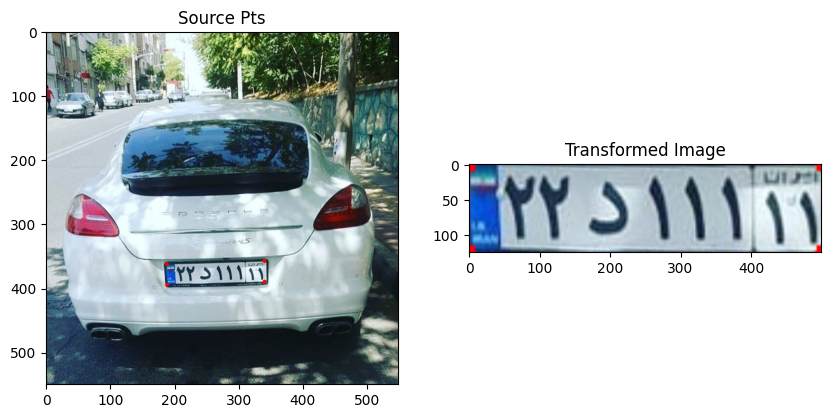

In [59]:
draw_img = img.copy()

source_pts = np.float32([
    [185 + 3, 360 + 3], # top-left
    [340, 355 + 3], # top-right
    [185 + 3, 355 + 40], # bottom-left
    [340, 350 + 40], # bottom-right
])

x, y, w, h = cv.boundingRect(source_pts)
aspect_ratio = w / float(h)
new_w = 500
target_size = np.int32([new_w, new_w * (1/aspect_ratio)])

target_pts = np.float32([
    [0, 0], # top-left
    [target_size[0], 0], # top-right
    [0, target_size[1]], # bottom-left
    [target_size[0], target_size[1]], # bottom-right
])

for pts in source_pts:
    cv.circle(draw_img, np.int32(pts), 3, (0,0,255), -1)

M = cv.getPerspectiveTransform(source_pts, target_pts)
output = cv.warpPerspective(draw_img, M, target_size)

plt.figure(figsize=(10,6))
plt.subplot(121); plt.imshow(draw_img[...,::-1]); plt.title("Source Pts")
plt.subplot(122); plt.imshow(output[...,::-1]); plt.title("Transformed Image")